## SHOCK DETECTION

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv('../data/processed/final_dataset.csv')

df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

#### Compute Inflation

In [3]:
df['cpi_pct_change'] = df['cpi'].pct_change() * 100
df['cpi_diff'] = df['cpi'].diff()
df['wpi_pct_change'] = df['wpi'].pct_change() * 100

In [4]:
# ==========================================
# ML SHOCK DETECTION (FIXED VERSION)
# ==========================================

# drop NaN first
df = df.dropna().copy()

# select features
features = df[['cpi_pct_change', 'cpi_diff', 'wpi_pct_change']]

# model
iso = IsolationForest(contamination=0.1, random_state=42)
df['shock_ml'] = iso.fit_predict(features)

# debug
print("ML shocks:", (df['shock_ml'] == -1).sum())

ML shocks: 17


#### Z-Score Method

In [5]:
mean = df['cpi_pct_change'].mean()
std = df['cpi_pct_change'].std()

df['z_score'] = (df['cpi_pct_change'] - mean) / std
df['shock_z'] = df['z_score'].abs() > 2

#### PLOT

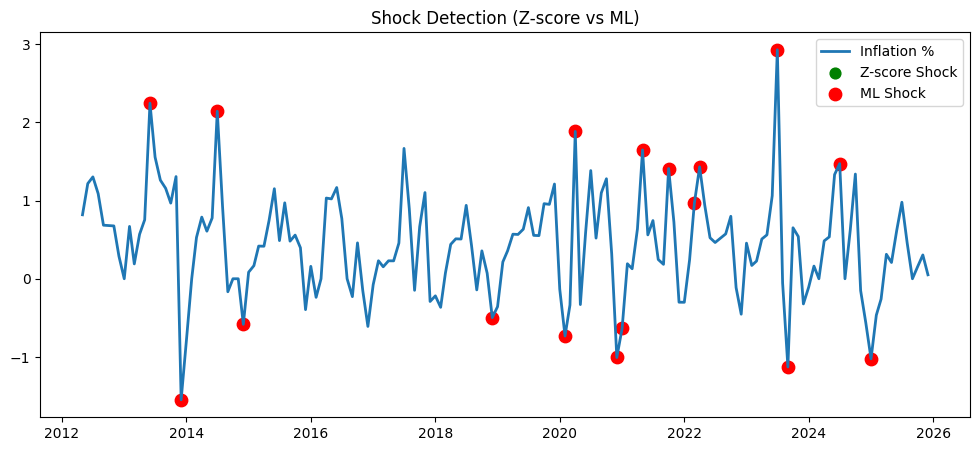

In [10]:
plt.figure(figsize=(12,5))

# line
plt.plot(df['date'], df['cpi_pct_change'], label='Inflation %', linewidth=2)

# Z-score shocks
plt.scatter(df[df['shock_z']]['date'],
            df[df['shock_z']]['cpi_pct_change'],
            color='green', s=60, label='Z-score Shock')

# ML shocks
ml_shocks = df[df['shock_ml'] == -1]

plt.scatter(ml_shocks['date'],
            ml_shocks['cpi_pct_change'],
            color='red', s=80, label='ML Shock')

plt.legend()
plt.title("Shock Detection (Z-score vs ML)")

plt.savefig('../reports/figures/shock_detection.png',
            dpi=300, bbox_inches='tight')

plt.show()


<Figure size 640x480 with 0 Axes>

In [8]:
print((df['shock_ml'] == -1).sum())

17
